In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import cortico_cereb_connectivity.run_model as rm

In [2]:
def heatmap_annotate(df_to_plot, ds_order, ax, ds_order_y=None, column=['train_dataset'], row=['eval_dataset'], value=['R_eval'], cmap='inferno', vmin=0, vmax=0.5):
    if ds_order_y is None:
        if 'Fusion' in ds_order:
            ds_order_y = [ds for ds in ds_order if ds!='Fusion']
        else:
            ds_order_y = ds_order
    V = pd.pivot_table(df_to_plot, columns=column, index=row, values=value)
    V = V.reindex(ds_order_y, axis=0)
    V = V.reindex(ds_order, level=1, axis=1)

    sns.heatmap(V.values, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax, 
                xticklabels=V.columns.get_level_values(1).values, 
                yticklabels=V.index.values, square=True, ax=ax)
    if 'Fusion' in ds_order:
        ax.axvline(len(ds_order_y), color='k', linewidth=2)

    return ax

In [3]:
method = 'L2reg'
cerebellum = 'MNISymC3'
train_ds_list = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]
eval_ds_list = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]
eval_names = ["MDTB", "Languagelocalizer", "Socialsocial", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]

df_all = pd.DataFrame()
for i, ds in enumerate(train_ds_list):
    eval_data = [ev_ds if ev_ds != "Language" else "Languagelocalizer" for ev_ds in eval_ds_list]
    eval_data = [ev_ds if ev_ds != "Social" else "Socialsocial" for ev_ds in eval_data]

    # load avg models
    df_1 = rm.comb_eval(models=[f'{ds}-avg-Cavg'], eval_data=eval_data, methods=[method], cerebellum=cerebellum)
    df_1["dataset_type"] = 'avg'

    # load loo models
    df_2 = rm.comb_eval(models=[f'{ds}-loo-Cavg'], eval_data=[eval_names[i]], methods=[method], cerebellum=cerebellum)
    df_2["dataset_type"] = 'avg'

    # load group models
    df_3 = rm.comb_eval(models=[f'{ds}-group-Cavg'], eval_data=eval_data, methods=[method], cerebellum=cerebellum)
    df_3["dataset_type"] = 'group'

    # load group_loo models
    df_4 = rm.comb_eval(models=[f'{ds}-group_loo-Cavg'], eval_data=[eval_names[i]], methods=[method], cerebellum=cerebellum)
    df_4["dataset_type"] = 'group'

    df_all = pd.concat([df_all, df_1, df_2, df_3, df_4], ignore_index=True)

df_avg = df_all[df_all['dataset_type'] == 'avg'].reset_index(drop=True)
df_group = df_all[df_all['dataset_type'] == 'group'].reset_index(drop=True)

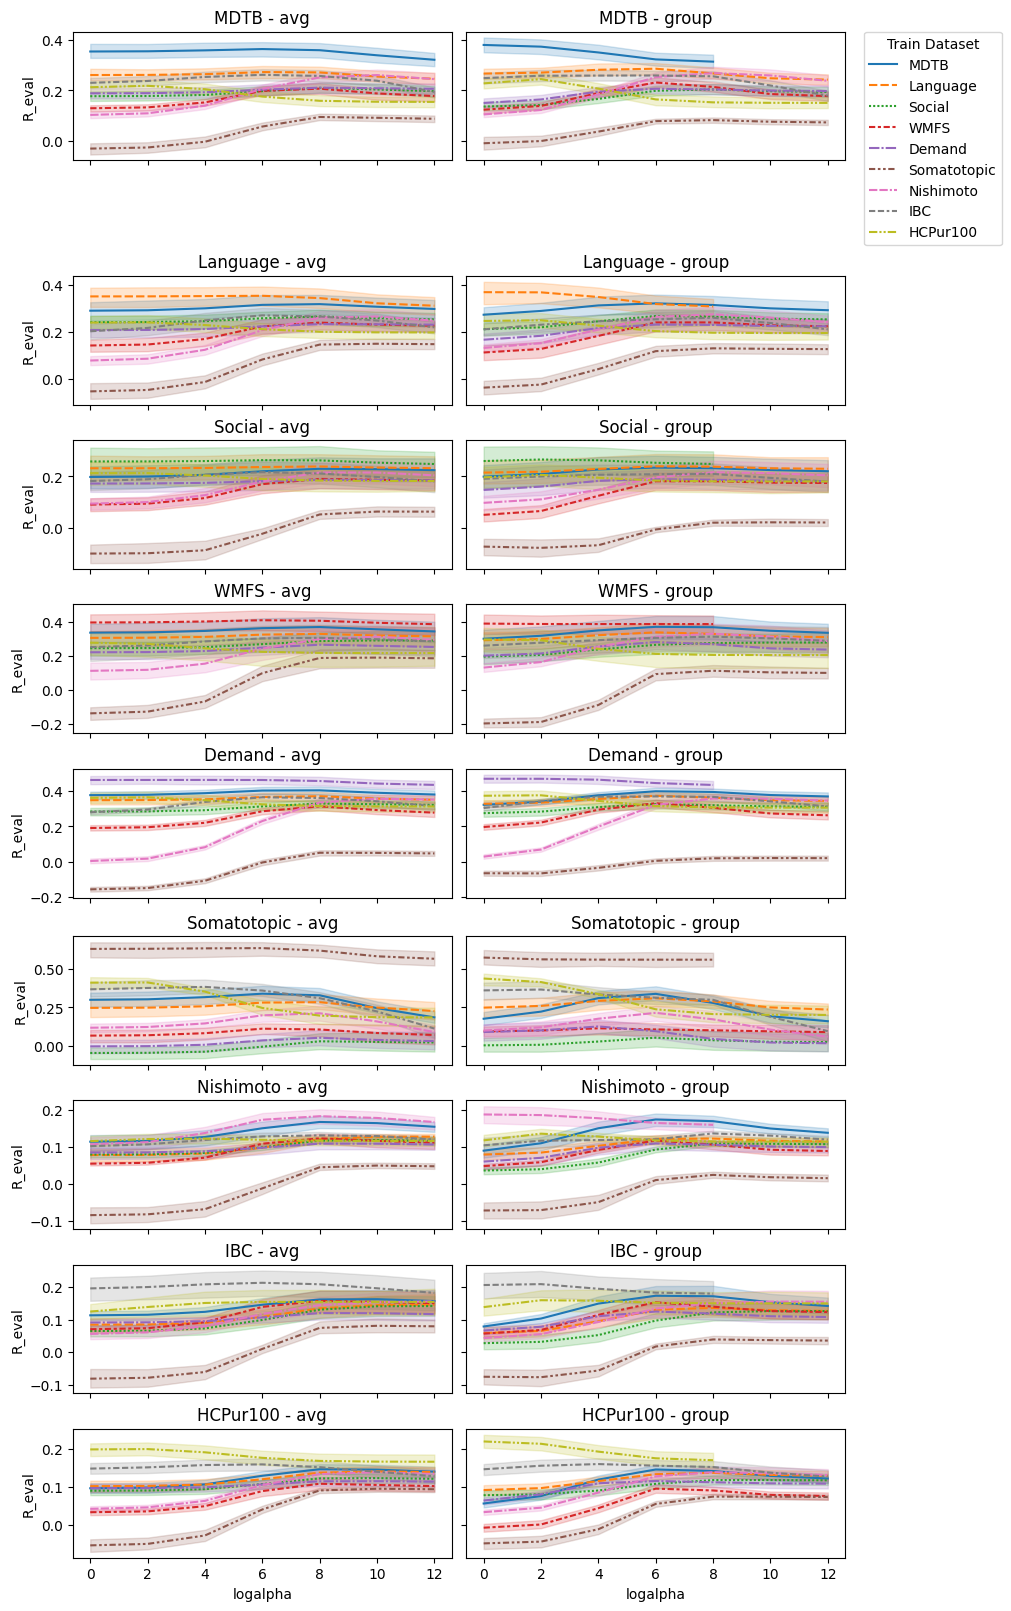

In [4]:
fig, axes = plt.subplots(len(eval_ds_list), 2, figsize=(10, 16), sharey='row', sharex='col', constrained_layout=True)
for i,ed in enumerate(eval_ds_list):
    # Left subplot
    ax_avg = axes[i, 0]
    df_to_plot = df_avg[df_avg.eval_dataset==ed]
    sns.lineplot(data=df_to_plot, y='R_eval', x='logalpha', hue='train_dataset', style='train_dataset',
                     hue_order=train_ds_list, style_order=train_ds_list, legend=False, ax=ax_avg)
    ax_avg.set_title(f'{ed} - avg')

    # Right subplot
    ax_group = axes[i, 1]
    df_to_plot = df_group[df_group.eval_dataset==ed]
    sns.lineplot(data=df_to_plot, y='R_eval', x='logalpha', hue='train_dataset', style='train_dataset',
                     hue_order=train_ds_list, style_order=train_ds_list, ax=ax_group)
    ax_group.set_title(f'{ed} - group')

    if i == 0:
        ax_group.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Train Dataset')
    else:
        ax_group.legend_.remove()

### Find best Hyperparameter

In [5]:
# avg
A = pd.pivot_table(df_avg, index=['train_dataset'],columns=['logalpha'],values=['R_eval'],aggfunc='mean').reindex(train_ds_list)
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_avg['isbest'] = df_avg.logalpha.values == bestla.loc[df_avg.train_dataset].values.flatten()

R_eval                                                    \
logalpha           0.0       2.0       4.0       6.0       8.0       10.0   
train_dataset                                                               
MDTB           0.242059  0.243714  0.251905  0.268562  0.275797  0.264579   
Language       0.227867  0.228446  0.232004  0.243487  0.250907  0.243181   
Social         0.176748  0.177458  0.181965  0.197975  0.212701  0.210448   
WMFS           0.126727  0.129847  0.147843  0.193565  0.209886  0.199124   
Demand         0.203104  0.203571  0.206376  0.215153  0.222037  0.217741   
Somatotopic   -0.057426 -0.052702 -0.025126  0.056334  0.111633  0.113077   
Nishimoto      0.063603  0.070555  0.103743  0.178124  0.227646  0.233846   
IBC            0.212073  0.220539  0.240526  0.251236  0.245064  0.227647   
HCPur100       0.245578  0.247757  0.234774  0.213619  0.203216  0.200958   

                         
logalpha           12.0  
train_dataset            
MDTB           0.253607  
Language       0.237936  
Social         0.207112  
WMFS           0.191922  
Demand         0.214275  
Somatotopic    0.110279  
Nishimoto      0.222202  
IBC            0.202267  
HCPur100       0.200621

,best_logalpha
train_dataset,
MDTB,8.0
Language,8.0
Social,8.0
WMFS,8.0
Demand,8.0
Somatotopic,10.0
Nishimoto,10.0
IBC,6.0
HCPur100,2.0


In [6]:
# group
A = pd.pivot_table(df_group, index=['train_dataset'],columns=['logalpha'],values=['R_eval'],aggfunc='mean').reindex(train_ds_list)
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_group['isbest'] = df_group.logalpha.values == bestla.loc[df_group.train_dataset].values.flatten()

R_eval                                                    \
logalpha           0.0       2.0       4.0       6.0       8.0       10.0   
train_dataset                                                               
MDTB           0.211954  0.227697  0.257666  0.272252  0.265581  0.240413   
Language       0.218960  0.224047  0.239369  0.251574  0.245766  0.227668   
Social         0.158520  0.164327  0.182293  0.202273  0.205740  0.196911   
WMFS           0.108814  0.121909  0.169840  0.210007  0.200166  0.165538   
Demand         0.184511  0.196071  0.219441  0.222931  0.215550  0.155990   
Somatotopic   -0.037822 -0.034862  0.001613  0.067298  0.083118  0.060679   
Nishimoto      0.074016  0.094702  0.159145  0.221791  0.237386  0.231746   
IBC            0.221507  0.237553  0.244914  0.244766  0.243908  0.224020   
HCPur100       0.257623  0.260571  0.233264  0.206992  0.199846  0.209006   

                         
logalpha           12.0  
train_dataset            
MDTB           0.231287  
Language       0.224001  
Social         0.195518  
WMFS           0.160259  
Demand         0.153885  
Somatotopic    0.059334  
Nishimoto      0.218826  
IBC            0.199778  
HCPur100       0.208835

,best_logalpha
train_dataset,
MDTB,6.0
Language,6.0
Social,8.0
WMFS,6.0
Demand,6.0
Somatotopic,8.0
Nishimoto,8.0
IBC,4.0
HCPur100,2.0


In [7]:
# Create a subset for best logalpha values
df_avg_best = df_avg[df_avg.isbest]
df_group_best = df_group[df_group.isbest]

### Evaluation Heatmap at best Hyperparameter

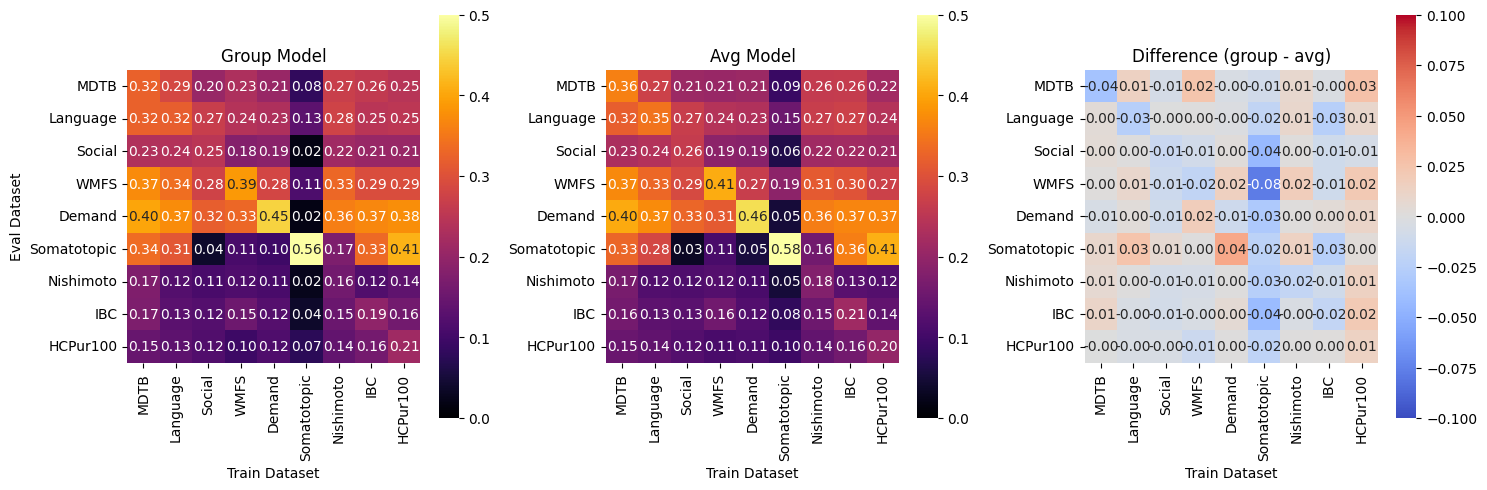

In [8]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

ax = heatmap_annotate(df_group_best, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[0], value=['R_eval'],
                      cmap='inferno', vmin=0, vmax=0.5)
ax.set_title('Group Model')
ax.set_xlabel('Train Dataset')
ax.set_ylabel('Eval Dataset')

ax = heatmap_annotate(df_avg_best, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[1], value=['R_eval'],
                      cmap='inferno', vmin=0, vmax=0.5)
ax.set_title('Avg Model')
ax.set_xlabel('Train Dataset')

# Calculate the difference in 'R_eval' for the same group of (train_dataset, eval_dataset, eval_subj)
df_diff = pd.merge(df_avg_best[['train_dataset', 'eval_dataset', 'eval_subj', 'R_eval']],
                   df_group_best[['train_dataset', 'eval_dataset', 'eval_subj', 'R_eval']],
                   on=['train_dataset', 'eval_dataset', 'eval_subj'],
                   suffixes=('_avg', '_group'))

df_diff['R_eval_diff'] = df_diff['R_eval_group'] - df_diff['R_eval_avg']
ax = heatmap_annotate(df_diff, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[2], value=['R_eval_diff'],
                      cmap='coolwarm', vmin=-0.1, vmax=0.1)
ax.set_title('Difference (group - avg)')
ax.set_xlabel('Train Dataset')

plt.tight_layout()

In [47]:
# Add Fusion model
df_fuse_avg = rm.comb_eval(models=["Fusion-avg-Cavg"], methods=[method], eval_data=["HCPur100"], cerebellum='MNISymC3')
df_fuse_avg['train_dataset'] = 'Fusion'
df_avg_on_HCP = df_avg_best[df_avg_best['eval_dataset'] == 'HCPur100'].reset_index(drop=True)
df_avg_on_HCP = pd.concat([df_avg_on_HCP, df_fuse_avg], ignore_index=True)
df_avg_on_HCP['dataset_type'] = 'avg'

df_fuse_group = rm.comb_eval(models=["Fusion-group-Cavg"], methods=[method], eval_data=["HCPur100"], cerebellum='MNISymC3')
df_fuse_group['train_dataset'] = 'Fusion'
df_group_on_HCP = df_group_best[df_group_best['eval_dataset'] == 'HCPur100'].reset_index(drop=True)
df_group_on_HCP = pd.concat([df_group_on_HCP, df_fuse_group], ignore_index=True)
df_group_on_HCP['dataset_type'] = 'group'

df_to_plot = pd.concat([df_avg_on_HCP, df_group_on_HCP], ignore_index=True)

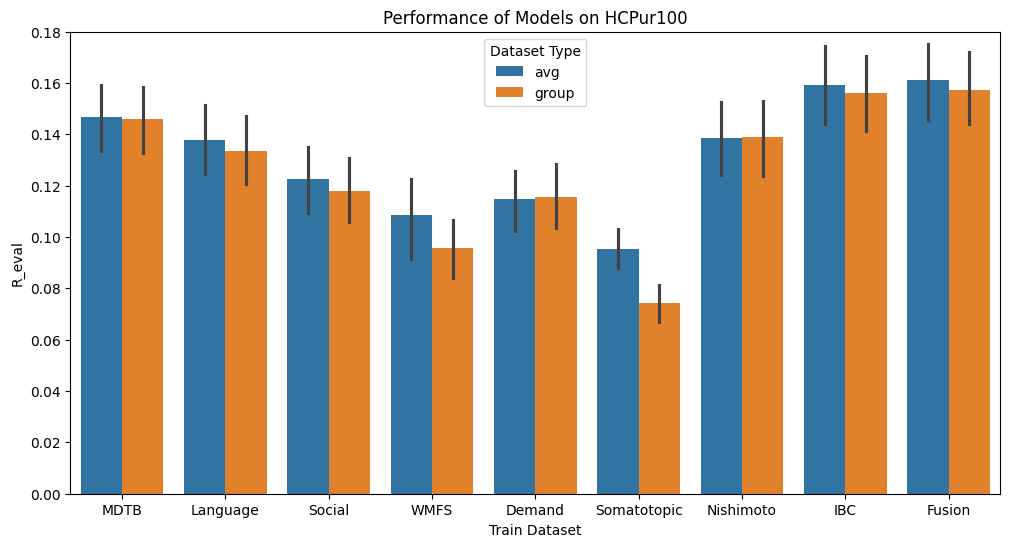

In [48]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_to_plot, x='train_dataset', y='R_eval', hue='dataset_type')
plt.title('Performance of Models on HCPur100')
plt.xlabel('Train Dataset')
plt.ylabel('R_eval')
plt.legend(title='Dataset Type')
plt.ylim(0, .18)
plt.show()

### Old data

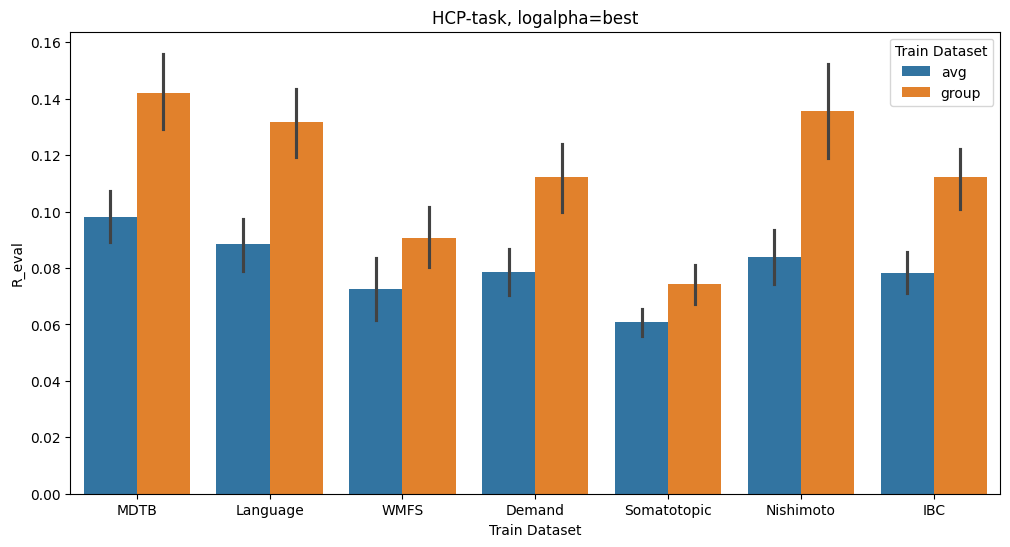

In [23]:
# Plot using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=df_all, x='train_dataset', y='R_eval', hue='dataset_type')
plt.title('HCP-task, logalpha=best')
plt.xlabel('Train Dataset')
plt.ylabel('R_eval')
plt.legend(title='Train Dataset')
plt.show()